Imports required:

In [221]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl as op

Creation of two bar plots - the first will visualise the average IMD rank for the North, Midlands and South of England, whilst the second will visualise the total crime rates, per offense group, by geographic region (North, Midlands and South of England).

North will encompass ITL1: 'North East', 'North West', 'Yorkshire and the Humber'
Midlands will encompass ITL1: 'East Midlands', 'West Midlands'
South will encompass ITL1: 'East', 'London', 'South East', 'South West'

IMD Rank - North, Midlands and South of England

,IMD Rank,IMD Decile,ITL1,ITL2
0,26525,8,London,Inner London - West
1,31203,10,London,Inner London - West


,IMD Rank,IMD Decile,Geographic Region,ITL2
0,26525,8,South,Inner London - West
1,31203,10,South,Inner London - West


Geographic Region
Midlands    16061.836786
North       14575.113807
South       18421.006373
Name: IMD Rank, dtype: float64

<class 'pandas.Series'>
<class 'pandas.DataFrame'>


,Geographic Region,IMD Rank
0,Midlands,16061.836786
1,North,14575.113807
2,South,18421.006373


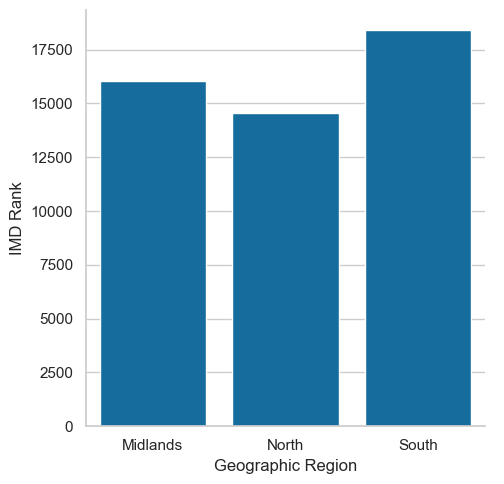

In [213]:
imd_df = pd.read_csv('clean_index_of_multiple_deprivation.csv')

# Visually checking the head of the data
display(imd_df.head(2))

# Renaming ITL1 regions and grouping into North, Midlands or South
imd_df_v2 = imd_df.replace({'North East (England)': 'North', 'North West (England)': 'North',\
                                'Yorkshire and The Humber': 'North', 'East Midlands (England)': 'Midlands',\
                               'West Midlands (England)': 'Midlands', 'East (England)': 'South', 'London':'South',\
                               'South East (England)':'South', 'South West (England)': 'South'}, inplace=True)
imd_df_v2.rename(columns={'ITL1': 'Geographic Region'}, inplace=True)

# Check changes have been made correctly
display(imd_df_v2.head(2))

# Average IMD ranking for each geographic region
imd_s = imd_df_v2.groupby(['Geographic Region'])['IMD Rank'].mean()
display(imd_s.head(20))

# To note: the .groupby() function has changed the df to a series
# Need to convert back to a df, to then use the seaborn .catplot() function
print(type(imd_s))
imd_df_v3 = imd_s.reset_index()
print(type(imd_df_v3))

display(imd_df_v3.head(5))

# Creating the graph
imd_graph = sns.catplot(
                data=imd_df_v3, kind='bar',
                x='Geographic Region', y='IMD Rank',
                alpha=1, color='#0072B2',
                height=5, aspect=1
)

plt.show()

Crime rates, by offense group - North, Midlands and South of England

,Unnamed: 0,Financial Year,Financial Quarter,Force Name,Offence Description,Offence Group,Offence Subgroup,Offence Code,Number of Offences,ITL1 region,ITL2 region
0,0,2024/25,1,Avon and Somerset,Absconding from lawful custody,Miscellaneous crimes against society,Miscellaneous crimes against society,80,2,South West (England),"['West of England', 'North Somerset, Somerset ..."
1,1,2024/25,1,Avon and Somerset,Abuse of children through sexual exploitation,Sexual offences,Other sexual offences,71,4,South West (England),"['West of England', 'North Somerset, Somerset ..."


,Unnamed: 0,Financial Year,Financial Quarter,Force Name,Offence Description,Offence Group,Offence Subgroup,Offence Code,Number of Offences,Geographic Region,ITL2 region
0,0,2024/25,1,Avon and Somerset,Absconding from lawful custody,Miscellaneous crimes against society,Miscellaneous crimes against society,80,2,South,"['West of England', 'North Somerset, Somerset ..."
1,1,2024/25,1,Avon and Somerset,Abuse of children through sexual exploitation,Sexual offences,Other sexual offences,71,4,South,"['West of England', 'North Somerset, Somerset ..."


Geographic Region  Offence Group                       
Midlands           Criminal damage and arson               0.080527
                   Drug offences                           0.028293
                   Miscellaneous crimes against society    0.021227
                   Possession of weapons offences          0.013588
                   Public order offences                   0.072502
                   Robbery                                 0.012110
                   Sexual offences                         0.038424
                   Theft offences                          0.284991
                   Violence against the person             0.355565
North              Criminal damage and arson               0.145917
                   Drug offences                           0.064740
                   Miscellaneous crimes against society    0.044179
                   Possession of weapons offences          0.017291
                   Public order offences                   0

count    27.000000
mean      0.183944
std       0.253562
min       0.012110
25%       0.033358
50%       0.072502
75%       0.195993
max       0.963184
Name: Number of Offences, dtype: float64

<class 'pandas.Series'>
<class 'pandas.DataFrame'>


,Geographic Region,Offence Group,Number of Offences (millions)
0,Midlands,Criminal damage and arson,0.080527
1,Midlands,Drug offences,0.028293
2,Midlands,Miscellaneous crimes against society,0.021227
3,Midlands,Possession of weapons offences,0.013588
4,Midlands,Public order offences,0.072502
5,Midlands,Robbery,0.012110
6,Midlands,Sexual offences,0.038424
7,Midlands,Theft offences,0.284991
8,Midlands,Violence against the person,0.355565
9,North,Criminal damage and arson,0.145917


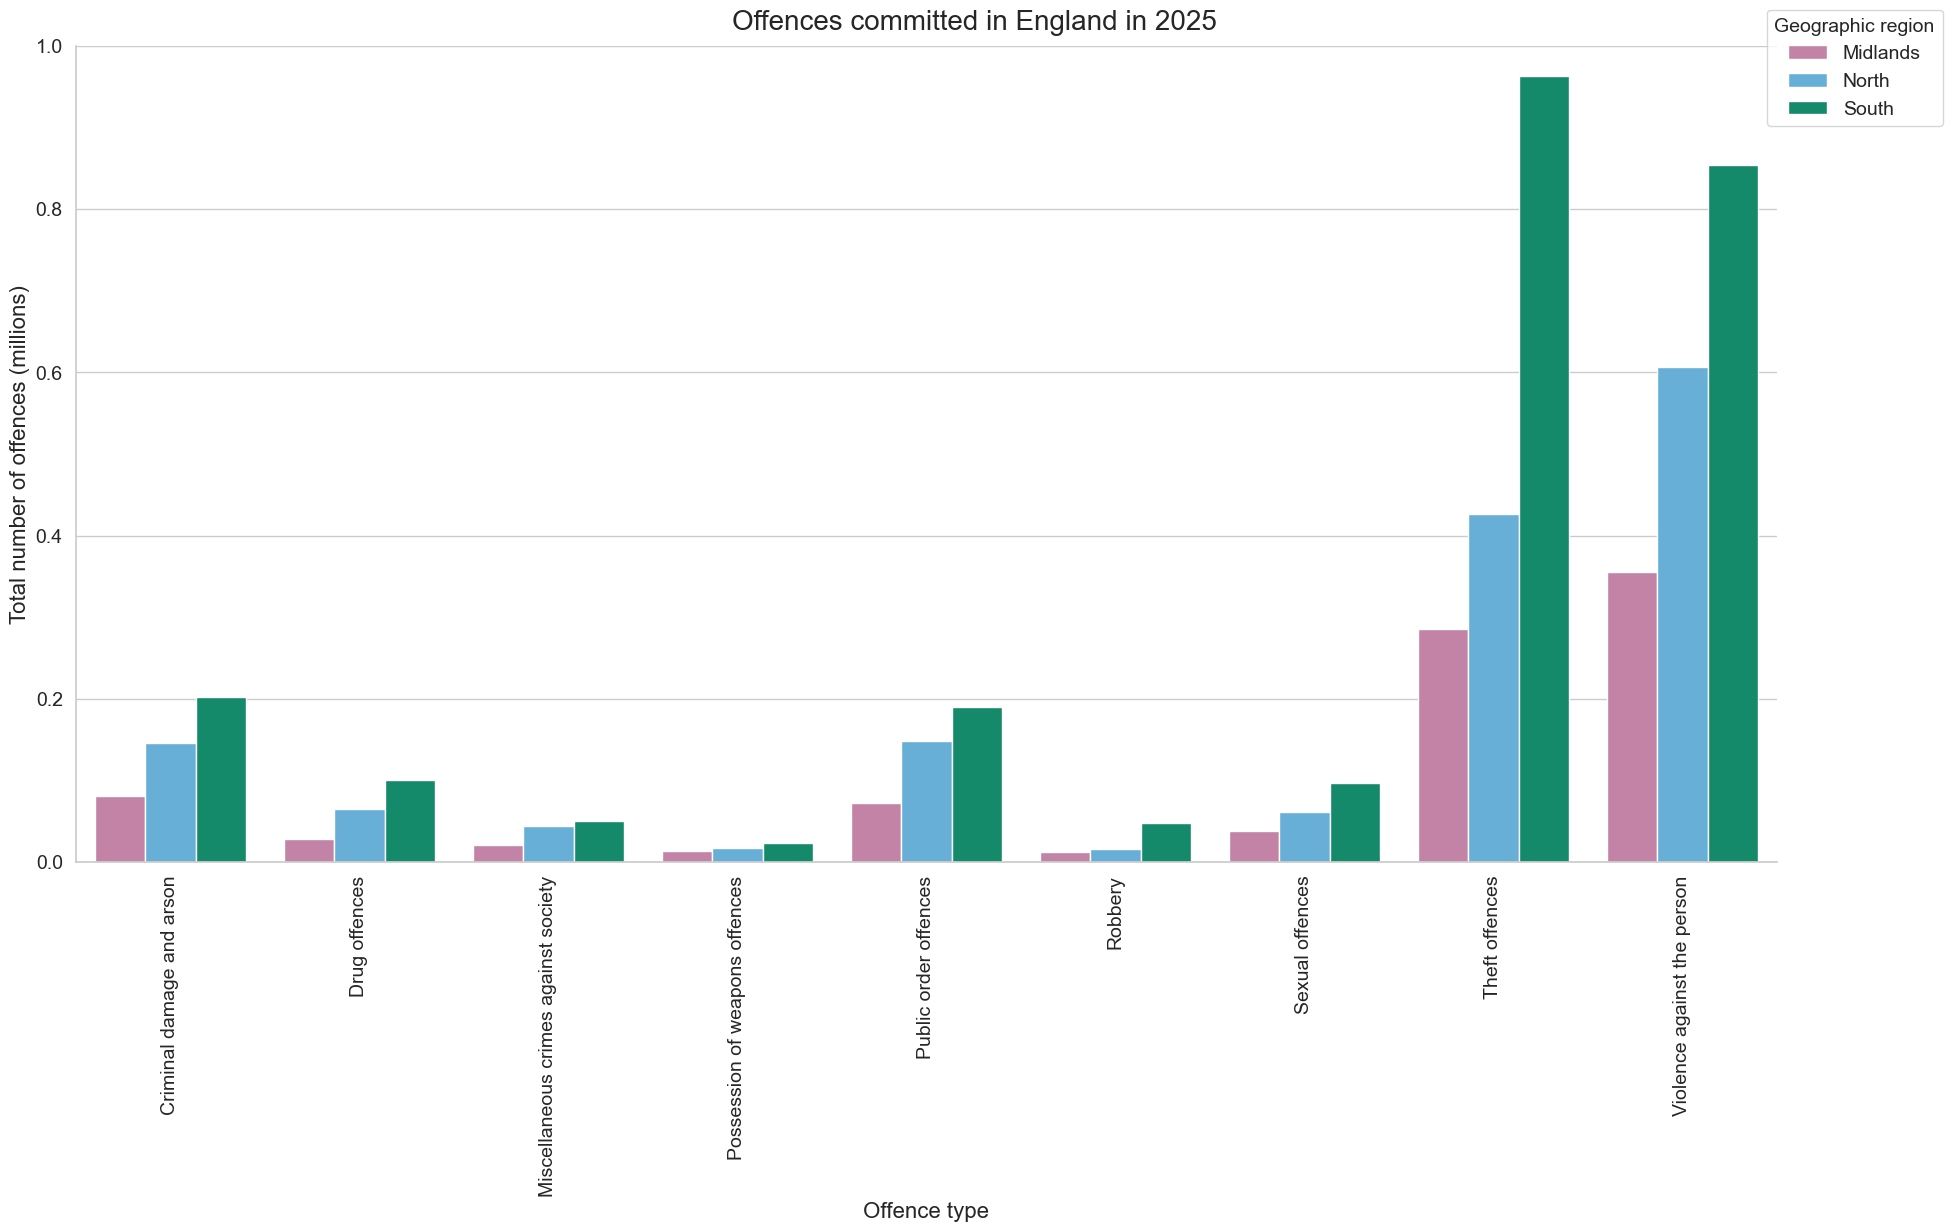

In [214]:
crime_df = pd.read_csv('CLEANED-regional_forces_crime_data_2024-2025.csv')

# Visually checking the head of the data
display(crime_df.head(2))

# Renaming ITL1 regions and grouping into North, Midlands or South
crime_df_v2 = crime_df.replace({'North East (England)': 'North', 'North West (England)': 'North',\
                                'Yorkshire and The Humber': 'North', 'East Midlands': 'Midlands',\
                               'West Midlands': 'Midlands', 'East (England)': 'South', 'London':'South',\
                               'South East (England)':'South', 'South West (England)': 'South'}, inplace=True)
crime_df_v2.rename(columns={'ITL1 region': 'Geographic Region'}, inplace=True)

# Check changes have been made correctly
display(crime_df_v2.head(2))

# Total offences by geographic region
# Preparing/grouping the dataset, as required for the following graph
# Number of offences unit is now in millions
crime_s = crime_df_v2.groupby(['Geographic Region', 'Offence Group'])['Number of Offences'].sum()/1e6
display(crime_s.head(20))

# Descriptive statistics for the number of offenses in England
display(crime_s.describe())

# To note: the .groupby() function has changed the df to a series
# Need to convert back to a df, to then use the seaborn .catplot() function
print(type(crime_s))
crime_df_v3 = crime_s.reset_index()
print(type(crime_df_v3))
crime_df_v3.rename(columns={'Number of Offences': 'Number of Offences (millions)'}, inplace=True)
display(crime_df_v3.head(100))

#Creating the graph
sns.set_theme(style='whitegrid')

# One of the best coluor palettes for colour blindness is 'okabeito'

okabeito = ['#CC79A7', '#56B4E9', '#009E73',\
           '#E69F00', '#0072B2', '#F0E442',\
           '#D55E00']
sns.set_palette(okabeito)

crime_graph = sns.catplot(
                data=crime_df_v3, kind='bar',
                x='Offence Group', y='Number of Offences (millions)',
                hue='Geographic Region', alpha=1, 
                height=9, aspect=2
)

crime_graph.fig.suptitle('Offences committed in England in 2025', y=1.02, fontsize=20)
crime_graph.set_xlabels('Offence type', fontsize=16)
crime_graph.set_ylabels('Total number of offences (millions)', fontsize=16, x=-1.05)
crime_graph.set_xticklabels(rotation=90, fontsize=14)
crime_graph.set_yticklabels(fontsize=14)
crime_graph.set(ylim=(0, 1))
crime_graph._legend.remove()
crime_graph.fig.legend(title='Geographic region', title_fontsize=14, fontsize=14)

plt.show()
# plt.savefig('Total offences committed in England in 2025 (North, South, Midlands)')

In [ ]:
Offence subgroups 

,Unnamed: 0,Financial Year,Financial Quarter,Force Name,Offence Description,Offence Group,Offence Subgroup,Offence Code,Number of Offences,ITL1 region,ITL2 region
0,0,2024/25,1,Avon and Somerset,Absconding from lawful custody,Miscellaneous crimes against society,Miscellaneous crimes against society,80,2,South West (England),"['West of England', 'North Somerset, Somerset ..."
1,1,2024/25,1,Avon and Somerset,Abuse of children through sexual exploitation,Sexual offences,Other sexual offences,71,4,South West (England),"['West of England', 'North Somerset, Somerset ..."


,Unnamed: 0,Financial Year,Financial Quarter,Force Name,Offence Description,Offence Group,Offence Subgroup,Offence Code,Number of Offences,Geographic Region,ITL2 region
0,0,2024/25,1,Avon and Somerset,Absconding from lawful custody,Miscellaneous crimes against society,Miscellaneous crimes against society,80,2,South,"['West of England', 'North Somerset, Somerset ..."
1,1,2024/25,1,Avon and Somerset,Abuse of children through sexual exploitation,Sexual offences,Other sexual offences,71,4,South,"['West of England', 'North Somerset, Somerset ..."


Geographic Region  Offence Subgroup                          
Midlands           Arson                                           4167
                   Bicycle theft                                   7403
                   Criminal damage                                76360
                   Death or serious injury - unlawful driving       469
                   Domestic burglary                                  0
                   Homicide                                          98
                   Miscellaneous crimes against society           21227
                   Non-domestic burglary                              0
                   Non-residential burglary                       13281
                   Other sexual offences                          24656
                   Other theft offences                           66485
                   Possession of drugs                            19309
                   Possession of weapons offences                 13588
  

count        75.000000
mean      66219.720000
std       81664.526603
min           0.000000
25%        8948.500000
50%       33645.000000
75%      100057.500000
max      384997.000000
Name: Number of Offences, dtype: float64

<class 'pandas.Series'>
<class 'pandas.DataFrame'>


,Geographic Region,Offence Subgroup,Number of Offences
0,Midlands,Arson,4167
1,Midlands,Bicycle theft,7403
2,Midlands,Criminal damage,76360
3,Midlands,Death or serious injury - unlawful driving,469
4,Midlands,Domestic burglary,0
5,Midlands,Homicide,98
6,Midlands,Miscellaneous crimes against society,21227
7,Midlands,Non-domestic burglary,0
8,Midlands,Non-residential burglary,13281
9,Midlands,Other sexual offences,24656


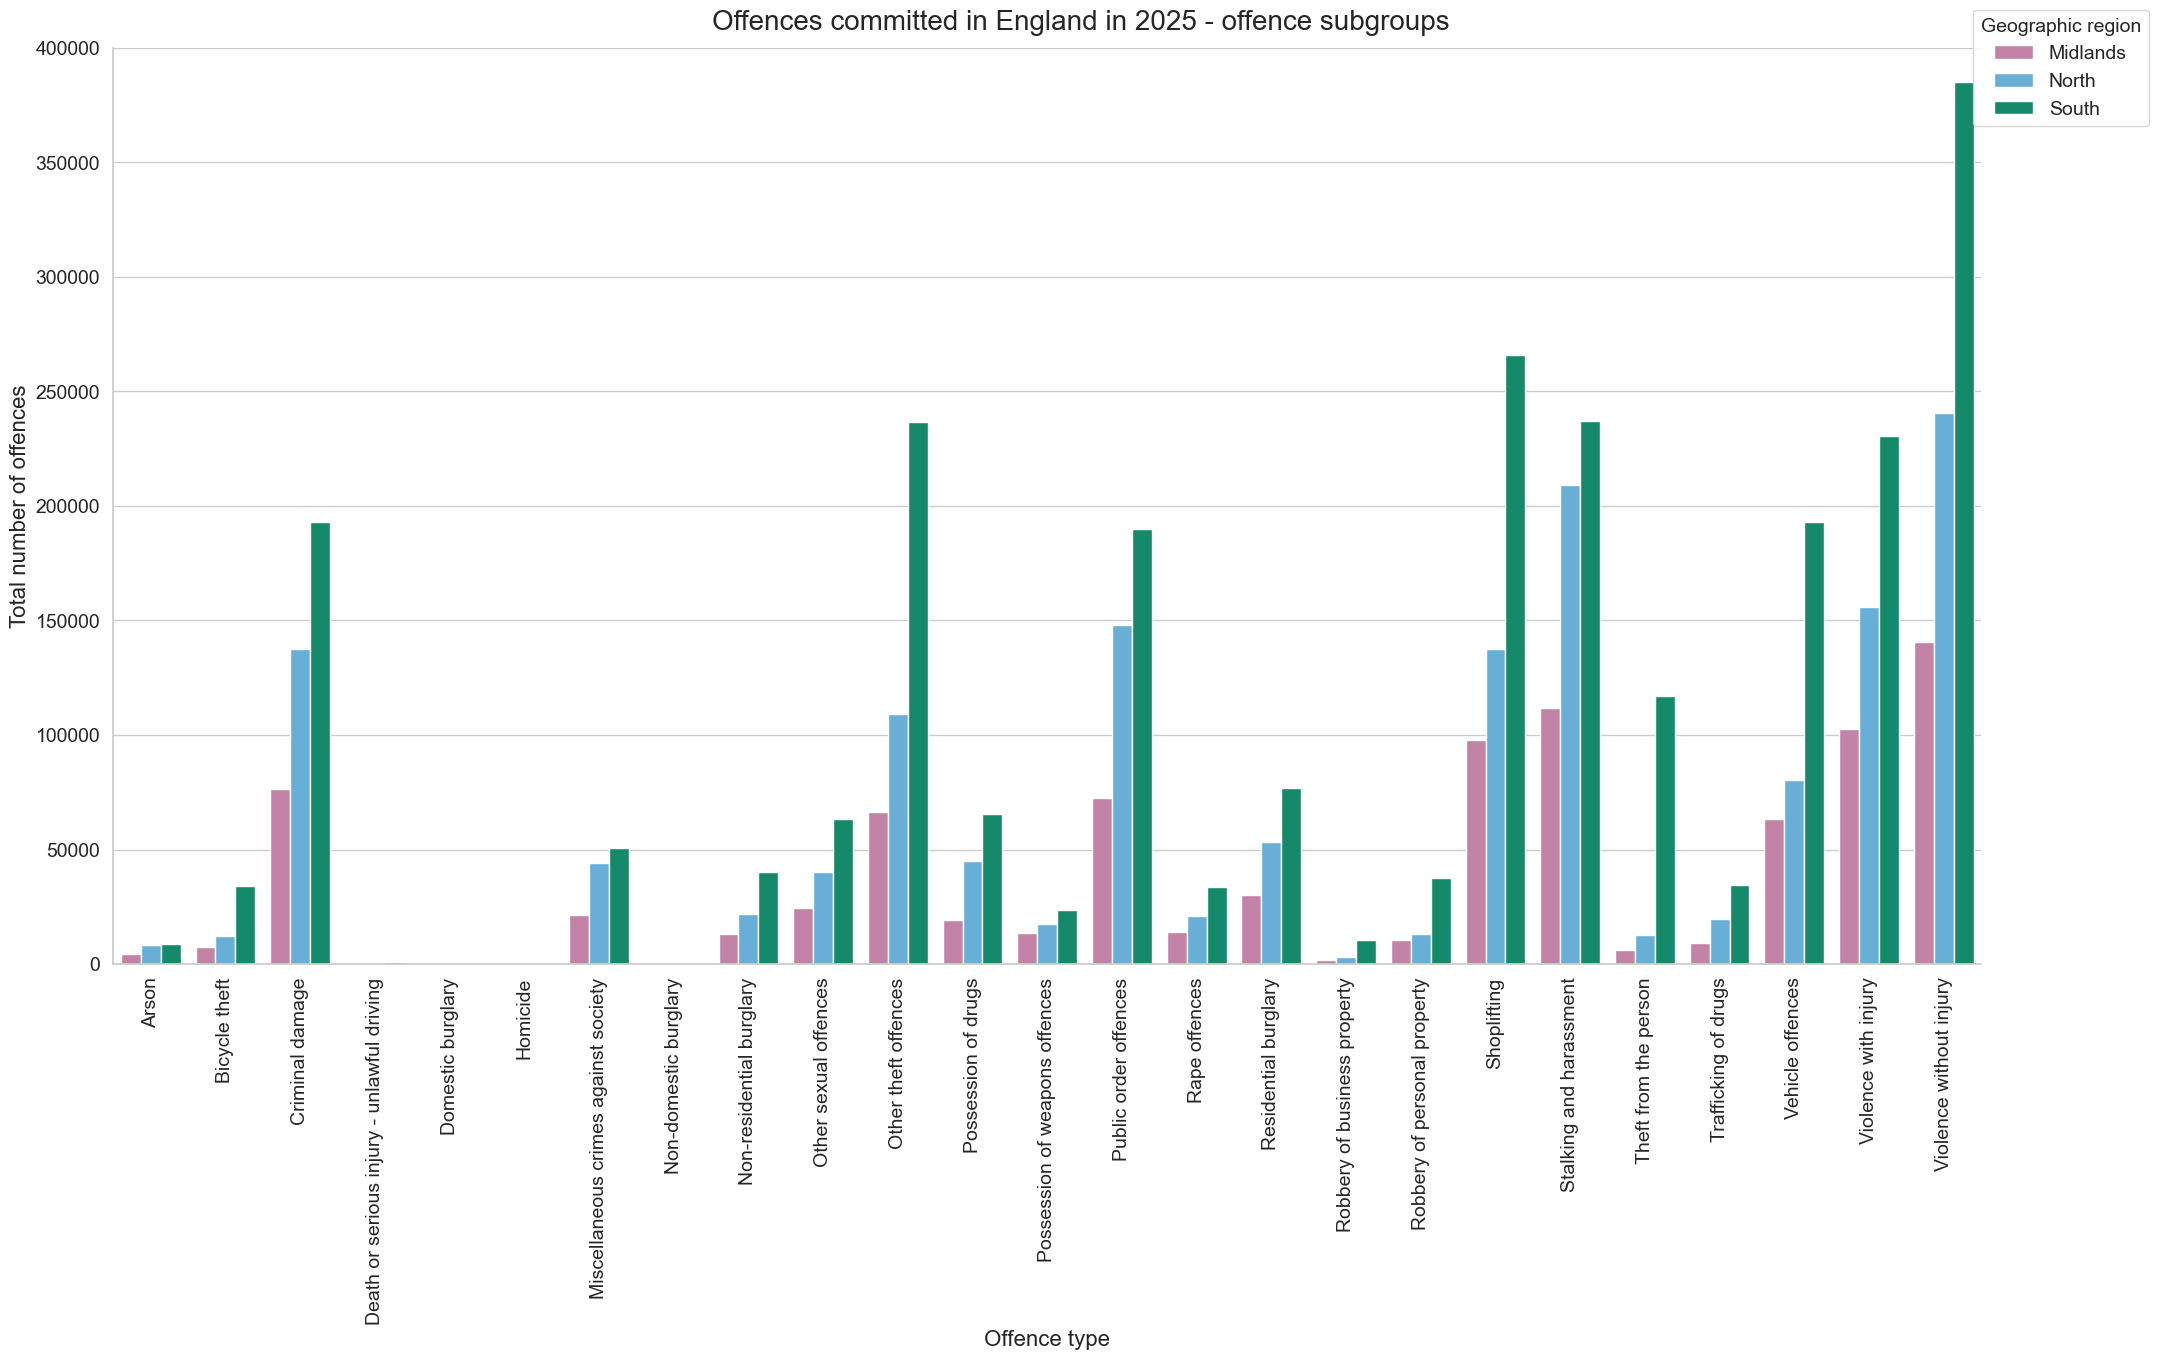

In [215]:
crime_df = pd.read_csv('CLEANED-regional_forces_crime_data_2024-2025.csv')

# Visually checking the head of the data
display(crime_df.head(2))

# Renaming ITL1 regions and grouping into North, Midlands or South
crime_df_v2 = crime_df.replace({'North East (England)': 'North', 'North West (England)': 'North',\
                                'Yorkshire and The Humber': 'North', 'East Midlands': 'Midlands',\
                               'West Midlands': 'Midlands', 'East (England)': 'South', 'London':'South',\
                               'South East (England)':'South', 'South West (England)': 'South'}, inplace=True)
crime_df_v2.rename(columns={'ITL1 region': 'Geographic Region'}, inplace=True)

# Check changes have been made correctly
display(crime_df_v2.head(2))

# Total offences by geographic region
# Preparing/grouping the dataset, as required for the following graph
# Number of offences unit is now in millions
crime_s = crime_df_v2.groupby(['Geographic Region', 'Offence Subgroup'])['Number of Offences'].sum()
display(crime_s.head(20))

# Descriptive statistics for the number of offenses in England
display(crime_s.describe())

# To note: the .groupby() function has changed the df to a series
# Need to convert back to a df, to then use the seaborn .catplot() function
print(type(crime_s))
crime_df_v3 = crime_s.reset_index()
print(type(crime_df_v3))
#crime_df_v3.rename(columns={'Number of Offences': 'Number of Offences (millions)'}, inplace=True)
display(crime_df_v3.head(50))

#Creating the graph
sns.set_theme(style='whitegrid')

# One of the best coluor palettes for colour blindness is 'okabeito'

okabeito = ['#CC79A7', '#56B4E9', '#009E73',\
           '#E69F00', '#0072B2', '#F0E442',\
           '#D55E00']
sns.set_palette(okabeito)

crime_graph = sns.catplot(
                data=crime_df_v3, kind='bar',
                x='Offence Subgroup', y='Number of Offences',
                hue='Geographic Region', alpha=1, 
                height=10, aspect=2
)

crime_graph.fig.suptitle('Offences committed in England in 2025 - offence subgroups', y=1.02, fontsize=20)
crime_graph.set_xlabels('Offence type', fontsize=16)
crime_graph.set_ylabels('Total number of offences', fontsize=16, x=-1.05)
crime_graph.set_xticklabels(rotation=90, fontsize=14)
crime_graph.set_yticklabels(fontsize=14)
crime_graph.set(ylim=(0, 400000))
crime_graph._legend.remove()
crime_graph.fig.legend(title='Geographic region', title_fontsize=14, fontsize=14)

plt.show()
# plt.savefig('Total offences committed in England in 2025 (North, South, Midlands)(subgroups)')

Weighted by population estimates (most recent are 2024, ONS
source: https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets/estimatesofthepopulationforenglandandwales?utm_source=chatgpt.com
Accessed on 21st June 2026

In [231]:
population_df = pd.read_excel('Mid-2024 Estimates of the population for England and Wales.xlsx', sheet_name='MYE2 - Persons')

display(population_df.head(10))

population_df.drop([4, 94], axis=1, inplace=True)

#population_df.drop(['Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'], axis=1, inplace=True)
display(population_df.head(10))
# Cleaning the dataset for use - for this graph
#population_df_v2 = population_df.drop((0), inplace=True)
# display(population_df_v2.head(10))

,"MYE2: Persons by single year of age and sex for local authorities in England and Wales, mid-2024",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 85,Unnamed: 86,Unnamed: 87,Unnamed: 88,Unnamed: 89,Unnamed: 90,Unnamed: 91,Unnamed: 92,Unnamed: 93,Unnamed: 94
0,This worksheet contains one table. Freeze pane...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,To turn off freeze panes select the 'View' rib...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Please choose from the links presented in the ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"This met my needs, please produce it next year",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,I need something slightly different (please sp...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,This is not what I need at all (please specify),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Code,Name,Geography,All ages,0.0,1.0,2.0,3.0,4.0,5.0,...,81.0,82.0,83.0,84.0,85.0,86.0,87.0,88.0,89.0,90+
7,K04000001,ENGLAND AND WALES,Country,61806682,601329.0,622020.0,660624.0,656038.0,680640.0,692020.0,...,369527.0,318021.0,271613.0,268602.0,251783.0,229508.0,201631.0,175142.0,149932.0,563609
8,E92000001,ENGLAND,Country,58620101,573812.0,593575.0,630059.0,625948.0,648849.0,659421.0,...,347609.0,298656.0,255001.0,253116.0,237616.0,216590.0,190245.0,165268.0,141650.0,532643
9,E12000001,NORTH EAST,Region,2760678,25050.0,25791.0,27324.0,27213.0,27955.0,29149.0,...,16203.0,14435.0,12824.0,12644.0,11779.0,10802.0,9621.0,7940.0,7000.0,24491


KeyError: '[4, 94] not found in axis'